In [5]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import urllib.request
import io
from PIL import Image
from dotenv import load_dotenv
import os
load_dotenv()

True

In [6]:
ee.Authenticate()
ee.Initialize(project=os.getenv('GOOGLE_PROJECT_ID'))

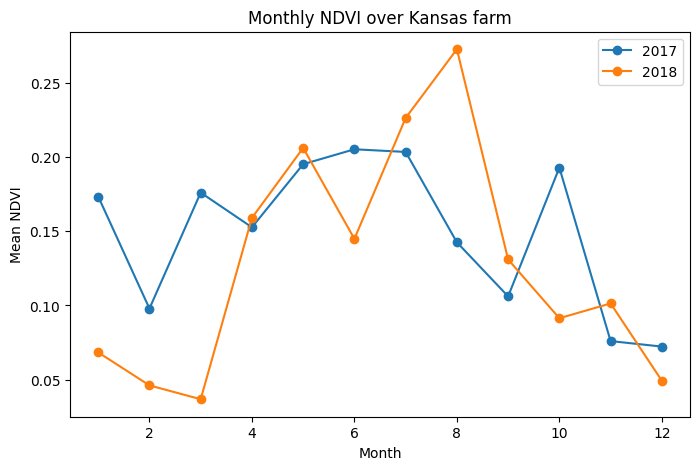

In [5]:
farm = ee.Geometry.Polygon([
    [[-97.5, 38.8], [-97.5, 38.7], [-97.4, 38.7], [-97.4, 38.8]]
])

# Function to add NDVI, but first select only B4 and B8
def addNDVI(image):
    image = image.select(['B4','B8'])  # ensure consistent bands
    ndvi = image.normalizedDifference(['B8','B4']).rename('NDVI')
    return image.addBands(ndvi)

dataset_2017 = ee.ImageCollection('COPERNICUS/S2') \
    .filterDate('2017-01-01','2017-12-31') \
    .filterBounds(farm) \
    .map(addNDVI)

dataset_2018 = ee.ImageCollection('COPERNICUS/S2') \
    .filterDate('2018-01-01','2018-12-31') \
    .filterBounds(farm) \
    .map(addNDVI)

# Monthly NDVI stats
def monthlyStats(year, dataset):
    months = ee.List.sequence(1,12)
    def byMonth(m):
        start = ee.Date.fromYMD(year, m, 1)
        end = start.advance(1,'month')
        img = dataset.filterDate(start,end).median().select('NDVI')
        mean = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=farm,
            scale=10,
            maxPixels=1e9
        )
        return ee.Feature(None, {'month': m, 'NDVI': mean.get('NDVI')})
    return ee.FeatureCollection(months.map(byMonth))

stats_2017 = monthlyStats(2017, dataset_2017).getInfo()
stats_2018 = monthlyStats(2018, dataset_2018).getInfo()

def to_df(stats, year):
    rows = [f['properties'] for f in stats['features']]
    df = pd.DataFrame(rows)
    df['year'] = year
    return df

df2017 = to_df(stats_2017, 2017)
df2018 = to_df(stats_2018, 2018)
df = pd.concat([df2017, df2018])

# Plot NDVI curves
plt.figure(figsize=(8,5))
for year, group in df.groupby('year'):
    plt.plot(group['month'], group['NDVI'], marker='o', label=str(year))
plt.xlabel('Month')
plt.ylabel('Mean NDVI')
plt.title('Monthly NDVI over Kansas farm')
plt.legend()
plt.show()


Fetching data for 2017...
Fetching data for 2018...
Fetching data for 2019...
Fetching data for 2020...
Fetching data for 2021...
Fetching data for 2022...
Fetching data for 2023...
Fetching data for 2024...
Fetching data for 2025...


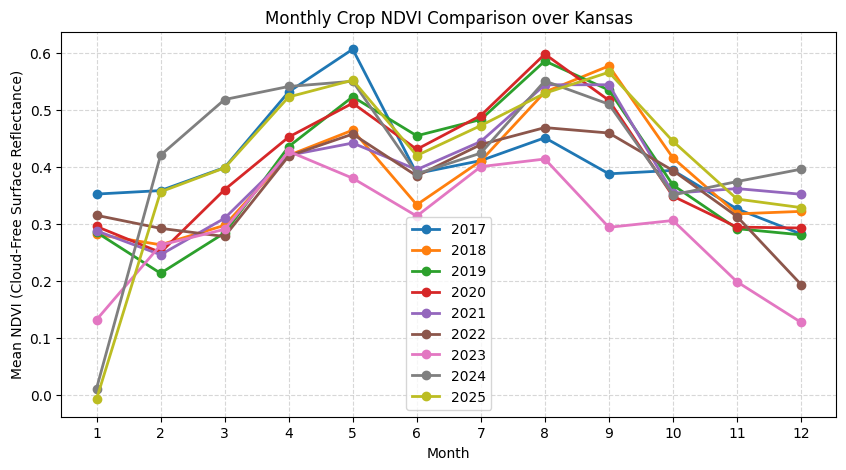

In [7]:

# 1. Define your farm (Note: Consider narrowing this down if it's a single field!)
farm = ee.Geometry.Polygon([
    [[-97.5, 38.8], [-97.5, 38.7], [-97.4, 38.7], [-97.4, 38.8]]
])

# 2. Cloud masking function for Sentinel-2 Surface Reflectance
def mask_s2_clouds(image):
    qa = image.select('QA60')
    # Bits 10 and 11 are clouds and cirrus, respectively.
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    # Both flags should be set to zero, indicating clear conditions.
    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(
           qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    return image.updateMask(mask)

# 3. NDVI function
def add_ndvi(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

# 4. Master function to get monthly stats for ANY year
def get_monthly_stats(year, geometry):
    # Use Harmonized Surface Reflectance for consistent multi-year tracking
    collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
        .filterDate(f'{year}-01-01', f'{year}-12-31') \
        .filterBounds(geometry) \
        .map(mask_s2_clouds) \
        .map(add_ndvi)
    
    months = ee.List.sequence(1, 12)
    
    def by_month(m):
        start = ee.Date.fromYMD(year, m, 1)
        end = start.advance(1, 'month')
        
        # Take the median of cloud-free pixels for that month
        img = collection.filterDate(start, end).median()
        
        # Reduce to mean NDVI over the farm area
        mean = img.select('NDVI').reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=geometry,
            scale=10, # Sentinel-2 B4 and B8 are 10m resolution
            maxPixels=1e9
        )
        return ee.Feature(None, {'month': m, 'year': year, 'NDVI': mean.get('NDVI')})
    
    return ee.FeatureCollection(months.map(by_month))

# 5. Fetch data for multiple years smoothly using a loop
years = [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
all_features = []

for y in years:
    print(f"Fetching data for {y}...")
    stats = get_monthly_stats(y, farm).getInfo()
    rows = [f['properties'] for f in stats['features']]
    all_features.extend(rows)

# 6. Create DataFrame
df = pd.DataFrame(all_features)

# 7. Plot clean NDVI curves
plt.figure(figsize=(10, 5))
for year, group in df.groupby('year'):
    # Dropping missing rows in case a month was entirely covered in clouds
    group = group.dropna() 
    plt.plot(group['month'], group['NDVI'], marker='o', linewidth=2, label=str(year))

plt.xlabel('Month')
plt.ylabel('Mean NDVI (Cloud-Free Surface Reflectance)')
plt.title('Monthly Crop NDVI Comparison over Kansas')
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()


--- Processing Dashboard for: Kansas Grain Basin (Bulk Sourcing) ---


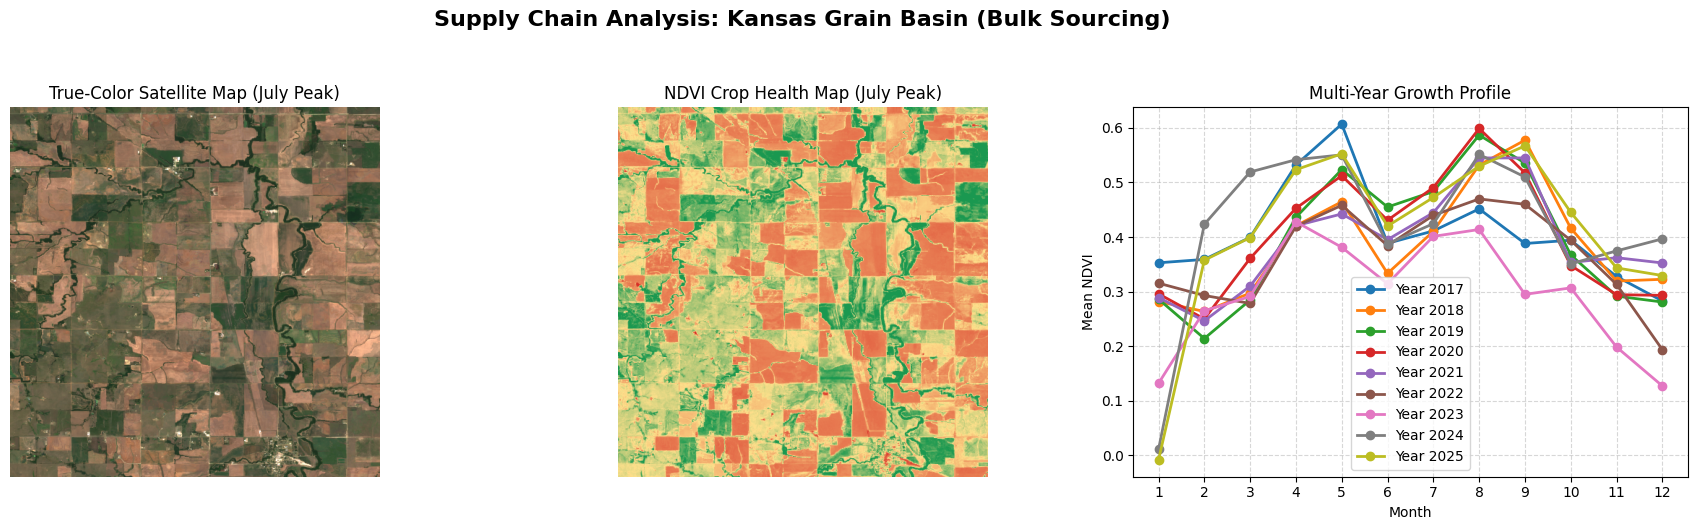


--- Processing Dashboard for: California Salinas Valley (Fresh Produce Hub) ---


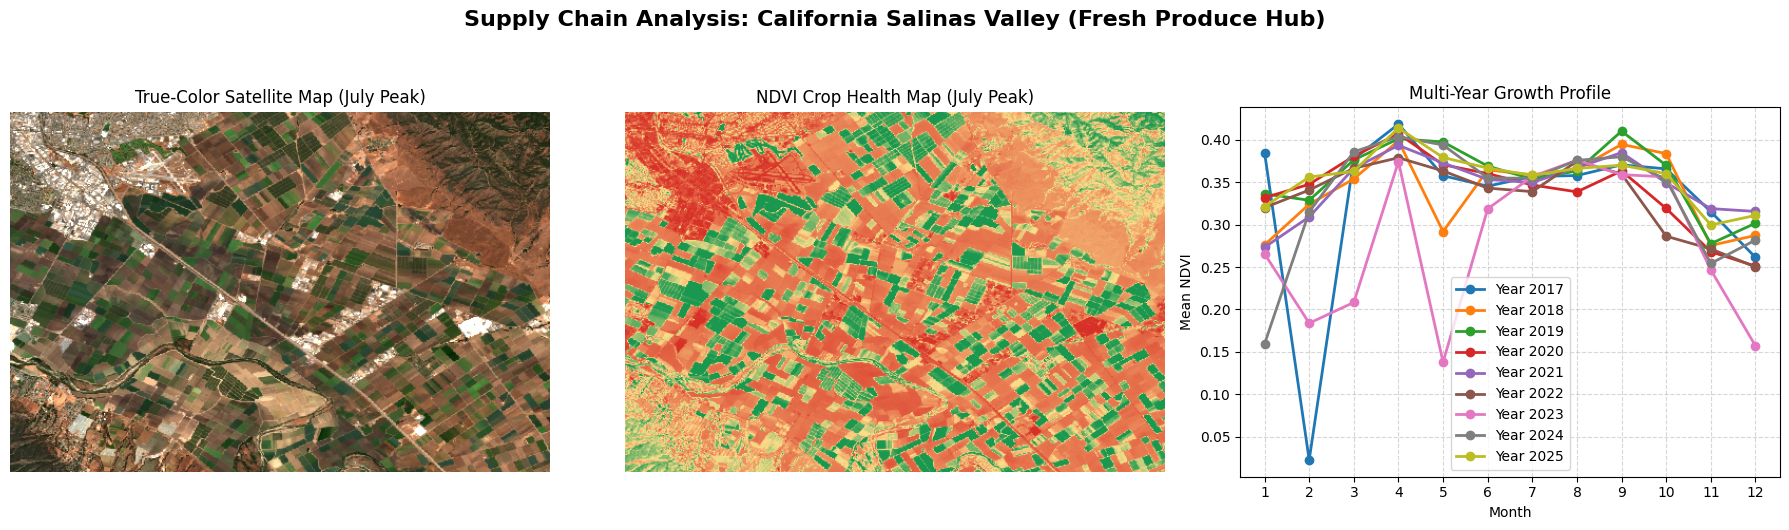

In [4]:
sourcing_hubs = {
    "Kansas Grain Basin (Bulk Sourcing)": ee.Geometry.Polygon([
        [[-97.5, 38.8], [-97.5, 38.7], [-97.4, 38.7], [-97.4, 38.8]]
    ]),
    "California Salinas Valley (Fresh Produce Hub)": ee.Geometry.Polygon([
        [[-121.65, 36.68], [-121.65, 36.58], [-121.50, 36.58], [-121.50, 36.68]]
    ])
}

# 2. Cloud Masking & NDVI Core Functions
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    return image.updateMask(mask)

def add_ndvi(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

# 3. Helper to fetch server-side map images into Python variables
def fetch_map_image(ee_image, geometry):
    try:
        url = ee_image.getThumbURL({'region': geometry, 'dimensions': 512, 'format': 'png'})
        response = urllib.request.urlopen(url)
        return Image.open(io.BytesIO(response.read()))
    except Exception as e:
        print(f"Error fetching map thumbnail: {e}")
        return None

# 4. Generate Dashboard for Each Hub
years = [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

for name, geometry in sourcing_hubs.items():
    print(f"\n--- Processing Dashboard for: {name} ---")
    
    # Track statistics across months
    all_rows = []
    for y in years:
        collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
            .filterDate(f'{y}-01-01', f'{y}-12-31') \
            .filterBounds(geometry) \
            .map(mask_s2_clouds) \
            .map(add_ndvi)
        
        months = ee.List.sequence(1, 12)
        def by_month(m):
            start = ee.Date.fromYMD(y, m, 1)
            end = start.advance(1, 'month')
            img = collection.filterDate(start, end).median()
            mean = img.select('NDVI').reduceRegion(
                reducer=ee.Reducer.mean(), geometry=geometry, scale=30, maxPixels=1e9
            )
            return ee.Feature(None, {'month': m, 'year': y, 'NDVI': mean.get('NDVI')})
        
        stats = ee.FeatureCollection(months.map(by_month)).getInfo()
        all_rows.extend([f['properties'] for f in stats['features']])
    
    df = pd.DataFrame(all_rows).dropna()

    # Get peak summer imagery (July 2018) for the visual maps
    peak_collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
        .filterDate('2018-07-01', '2018-07-31') \
        .filterBounds(geometry) \
        .map(mask_s2_clouds) \
        .map(add_ndvi)
    
    peak_median = peak_collection.median()
    
    # Create True-Color Visualization
    rgb_vis = peak_median.visualize(bands=['B4', 'B3', 'B2'], min=0, max=2500)
    img_rgb = fetch_map_image(rgb_vis, geometry)
    
    # Create NDVI Heatmap Visualization (Red = Bare soil, Yellow = Mild, Green = Dense Crops)
    ndvi_vis = peak_median.select('NDVI').visualize(min=0, max=0.8, palette=['#d73027', '#fee08b', '#1a9850'])
    img_ndvi = fetch_map_image(ndvi_vis, geometry)

    # 5. Build the Side-by-Side Plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Supply Chain Analysis: {name}", fontsize=16, fontweight='bold', y=1.05)
    
    # Panel 1: Satellite View
    if img_rgb:
        axes[0].imshow(img_rgb)
    axes[0].set_title("True-Color Satellite Map (July Peak)")
    axes[0].axis('off')
    
    # Panel 2: Crop Health Heatmap
    if img_ndvi:
        axes[1].imshow(img_ndvi)
    axes[1].set_title("NDVI Crop Health Map (July Peak)")
    axes[1].axis('off')
    
    # Panel 3: Multi-Year Line Graph
    for year, group in df.groupby('year'):
        axes[2].plot(group['month'], group['NDVI'], marker='o', linewidth=2, label=f"Year {year}")
    
    axes[2].set_title("Multi-Year Growth Profile")
    axes[2].set_xlabel("Month")
    axes[2].set_ylabel("Mean NDVI")
    axes[2].set_xticks(range(1, 13))
    axes[2].grid(True, linestyle='--', alpha=0.5)
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()
